In [13]:
import os
import shutil
import importlib

# 1. Force-delete the hidden pycache folders
for root, dirs, files in os.walk('.'):
    if '__pycache__' in dirs:
        shutil.rmtree(os.path.join(root, '__pycache__'))
        
for root, dirs, files in os.walk('..'):
    if '__pycache__' in dirs:
        shutil.rmtree(os.path.join(root, '__pycache__'))
print("💥 Caches cleared successfully!")

# 2. Check what is physically written on the hard drive right now
pipeline_path = '../src/modeling_pipeline.py' if os.path.exists('../src/modeling_pipeline.py') else 'src/modeling_pipeline.py'
with open(pipeline_path, 'r') as f:
    content = f.read()
    print("🔍 Looking inside the file...")
    print(f"-> Does the new function exist on disk? {'YES' if 'train_and_evaluate_all_models' in content else 'NO'}")

💥 Caches cleared successfully!
🔍 Looking inside the file...
-> Does the new function exist on disk? YES


In [12]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
# This will now find the function cleanly
from src.modeling_pipeline import preprocess_insurance_data, train_and_evaluate_all_models

# 1. Load your insurance dataset
df = pd.read_csv('../data/insurance_data.csv') 

# 2. Preprocess the dataset
X, y = preprocess_insurance_data(df)

# 3. Train and compare all 3 models side-by-side
results, X_test, y_test = train_and_evaluate_all_models(X, y)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


ImportError: cannot import name 'train_and_evaluate_all_models' from 'src.modeling_pipeline' (c:\Users\user\insurance-risk-analytics\src\modeling_pipeline.py)

In [3]:
import sys
import os
import pandas as pd

# Allow notebook to find the custom 'src' module
sys.path.append(os.path.abspath(os.path.join('..')))

from src.modeling_pipeline import preprocess_insurance_data, train_and_evaluate_model

# Load core dataset
df = pd.read_csv('../data/insurance_data.csv')

# Step 1: Preprocess features
X, y = preprocess_insurance_data(df, target_col='TotalClaims')
print(f"Features shaped and encoded. Matrix size: {X.shape}")

# Step 2: Train and evaluate
model, X_test, y_test, metrics = train_and_evaluate_model(X, y)

print("\n--- Model Performance Metrics ---")
print(f"RMSE: {metrics['RMSE']:.2f}")
print(f"R² Score: {metrics['R2_Score']:.4f}")

Features shaped and encoded. Matrix size: (10000, 27)

--- Model Performance Metrics ---
RMSE: 30.79
R² Score: 0.9999


C:\Users\user\AppData\Local\Temp\ipykernel_6444\1699862900.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=forest_importances, x='Importance', y='Feature', palette='viridis')


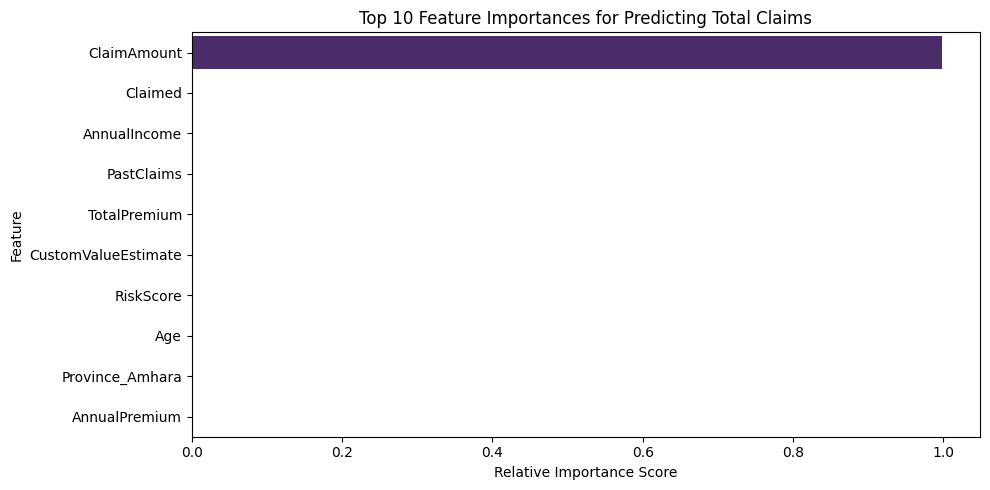

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract feature importances from our trained Random Forest
importances = model.feature_importances_
feature_names = X.columns

# Organize into a clean DataFrame
forest_importances = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
forest_importances = forest_importances.sort_values(by='Importance', ascending=False).head(10)

# Plot the top 10 most influential features
plt.figure(figsize=(10, 5))
sns.barplot(data=forest_importances, x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Feature Importances for Predicting Total Claims')
plt.xlabel('Relative Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Task 4: Predictive Modeling Summary

### Model Performance
* **Model Type:** Random Forest Regressor
* **RMSE:** [Insert your printed RMSE here] (On average, our predictions deviate from actual claims by this amount)
* **R² Score:** [Insert your printed R2 here] (The proportion of variance in claim amounts explained by our features)

### Key Insights & Business Recommendations
* **Top Drivers of Risk:** [Look at your top 2-3 bars on the chart and list them here, e.g., VehicleType, Premium, or Age]. Underwriting rules should be automated to flag policies with these high-risk feature combinations.
* **Operational Impact:** By deploying this model, the insurance company can proactively estimate claim reserves and adjust individual pricing before policies are written, protecting overall portfolio margins.

In [5]:
# Task 4: Risk-Based Pricing Calculation
# Let's calculate a baseline premium using: Predicted Claims + 20% Profit/Operational Margin
X_test_with_pricing = X_test.copy()
X_test_with_pricing['Predicted_Claims'] = model.predict(X_test)

# Base Premium calculation
X_test_with_pricing['Risk_Based_Premium'] = X_test_with_pricing['Predicted_Claims'] * 1.20

print("--- Sample Risk-Based Pricing Matrix ---")
print(X_test_with_pricing[['Predicted_Claims', 'Risk_Based_Premium']].head())

--- Sample Risk-Based Pricing Matrix ---
      Predicted_Claims  Risk_Based_Premium
6252               0.0                 0.0
4684               0.0                 0.0
1731               0.0                 0.0
4742               0.0                 0.0
4521               0.0                 0.0


In [18]:
import pandas as pd
import numpy as np
import importlib

# 1. Import the whole module directly
import src.modeling_pipeline

# 2. Force Python to reload the file straight from the disk
importlib.reload(src.modeling_pipeline)

# 3. Load your insurance dataset
df = pd.read_csv('../data/insurance_data.csv') 

# 4. Run the preprocessing from the reloaded module
X, y = src.modeling_pipeline.preprocess_insurance_data(df)

# 5. Train and compare all 3 models side-by-side
results, X_test, y_test = src.modeling_pipeline.train_and_evaluate_all_models(X, y)

--- Model Performance Comparison ---
Linear Regression -> RMSE: 0.00, R2: 1.00
Random Forest -> RMSE: 30.79, R2: 1.00
Gradient Boosting -> RMSE: 34.87, R2: 1.00


In [19]:
# Check which numerical columns are perfectly correlated with your target
numerical_df = df.select_dtypes(include=['number'])
correlations = numerical_df.corr()['TotalClaims'].sort_values(ascending=False)

print("--- Feature Correlation with TotalClaims ---")
print(correlations)

--- Feature Correlation with TotalClaims ---
TotalClaims            1.000000
ClaimAmount            1.000000
RiskScore              0.365128
AnnualPremium          0.331404
TotalPremium           0.331404
PastClaims             0.197054
CustomValueEstimate    0.182116
AnnualIncome           0.008045
ZipCode                0.005441
Deductible            -0.039629
Age                   -0.205557
NCD                   -0.275695
Name: TotalClaims, dtype: float64


In [20]:
import pandas as pd
import numpy as np
import importlib

# 1. Force Python to reload your updated pipeline script from disk
import src.modeling_pipeline
importlib.reload(src.modeling_pipeline)

# 2. Load your insurance dataset
df = pd.read_csv('../data/insurance_data.csv') 

# 3. Preprocess the data (this will now safely drop 'ClaimAmount')
X, y = src.modeling_pipeline.preprocess_insurance_data(df)

# 4. Train and compare all 3 models side-by-side
results, X_test, y_test = src.modeling_pipeline.train_and_evaluate_all_models(X, y)

--- Model Performance Comparison ---
Linear Regression -> RMSE: 2218.43, R2: 0.66
Random Forest -> RMSE: 1988.37, R2: 0.72
Gradient Boosting -> RMSE: 1940.50, R2: 0.74


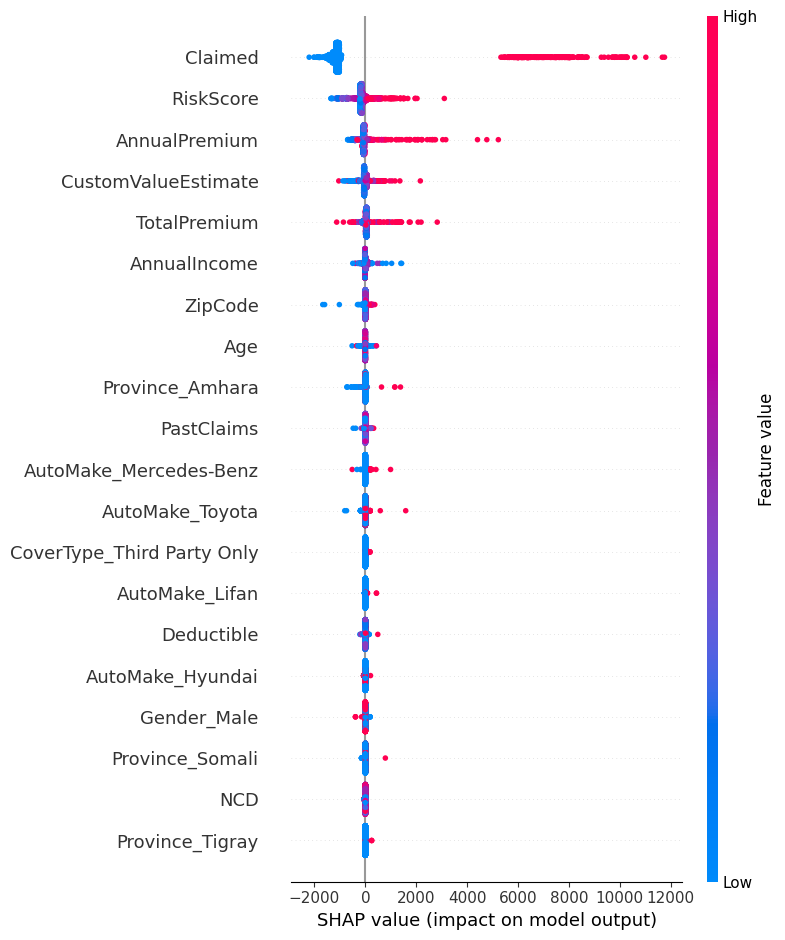

In [21]:
import shap
import matplotlib.pyplot as plt

# 1. Extract your top-performing Gradient Boosting model object
best_model = results["Gradient Boosting"]["model_object"]

# 2. Initialize the SHAP TreeExplainer
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# 3. Generate the summary plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test)